# 

# Mediation Simulation, with Selection into Treatment

Senan Hogan-Hennessy

In [4]:
# Show the date:
print(paste("Compiled at", format(Sys.time(), "%H:%M %Z %A, %d %B %Y")))
# Set up the R environment
set.seed(47)
# Load tidyverse, for dealing with data and plotting.
library(tidyverse)
# Define number of digits in tables and graphs.
digits.no <- 3

[1] "Compiled at 13:21 EDT Sunday, 07 July 2024"


This document simulates a system, where a randomised measure $Z$ affects an outcome $Y$ via two channels: directly $Z \to Y$, and indirectly via a mediator $D(Z) \to Y$.
Under structural assumptions, various messages partially identify the system: this simulation builds intuition for how they behave under different structual paramter values.

## Notation

https://jupyterbook.org/en/stable/content/math.html
https://docs.mathjax.org/en/v2.7-latest/tex.html#automatic-equation-numbering

Suppose $\vec X_i$ represents a vector of covariates, say demographic information, on individuals $i = 1, \dots, N$.
UNFINISHED: Continued defining the system in terms of Z, D(Z), Y.

Then write about how this system would be identified if observe both $\vec{X}_i, U_i$, but only observe $\vec X_i$.
Then introduce assumption, $U_{0,i}, U_{0,i} \sim \text{BivarNormal}(\rho,0,0,\sigma_0, \sigma_1)$.

## Simulation

The below defines a function to simulate the system, under user-specified $rho, \sigma_0, \sigma_1$ values, $N = 1,000$.
Covariates are a vector composed of $X_{k, i} \sim U(0, 1)$ for $k = 1, \dots, 10$, with the following $\mu_D(Z; \vec X_i)$ definitions --- where $|.|^p$ is the $L^p$ norm.
\begin{align*}
    \mu_0(0; \vec X_i) &= 10 \\
    \mu_1(0; \vec X_i) &= 2 \mu_0(0; \vec X_i) \times | \vec X_i |^1 \\
    \mu_0(1; \vec X_i) &= 2 \times \mu_0(0; \vec X_i) \\
    \mu_1(1; \vec X_i) &= 3.5 \mu_0(0; \vec X_i) \left( | \vec X_i |^1 \right)^{\frac12}
\end{align*}
These values, while defined, are not important beyond ensuring no defiers (i.e., $D_i(0) \leq D_i(1)$ for all) under reasonable $\rho, \sigma_0, \sigma_1$ values.

In [5]:
################################################################################
## Define a function to simulate data in the triangular system.
simulate.data <- function(X.matrix, rho, sigma_0, sigma_1,
    sample.size = 10^3){
    ### Inputs:
    ## X, a matrix of covariates, continuous or binary values.
    ## rho \in [-1, +1] measuring correlation between U_0, U_1.
    ## sigma_0 >= 0 measuring standard deviation of U_0.
    ## sigma_1 >= 0 measuring standard deviation of U_1.
    ## sample.size: integer, representing output sample size i.e., N.
    
    # Generate outcomes as sum of observed, \mu_D(Z; X), + unobserved, U
    treatment_index_X <- rowSums(X.matrix)
    mu0_Z0_X <- rep(10, sample.size)
    mu1_Z0_X <- (2 * treatment_index_X) * mean(mu0_Z0_X)
    mu0_Z1_X <- mu0_Z0_X * 2
    mu1_Z1_X <- (3.5 * treatment_index_X^0.5) * mean(mu0_Z0_X)
    # Unobserved selection, between D = 1 and D = 0
    # Assume: U_1, U_0 ~ BivarNormal(rho, mu_0 = mu_1 = 0, sigma_0, sigma_1)
    U_both <- MASS::mvrnorm(
        n = sample.size,
        mu = c(0, 0),
        Sigma = matrix(c(
            sigma_0^2, rho * sigma_0 * sigma_1,
            rho * sigma_0 * sigma_1, sigma_1^2
        ), ncol = 2)
    )
    U_0 <- U_both[, 1]
    U_1 <- U_both[, 2]
    # Compose potential outcomes from the observed + unobserved factors.
    # Y_i(Z, D) = mu_D(Z; X_i) + U_D
    Y_0_0 <- mu0_Z0_X + U_0
    Y_0_1 <- mu1_Z0_X + U_1
    Y_1_0 <- mu0_Z1_X + U_0
    Y_1_1 <- mu1_Z1_X + U_1
    # Model compliance as pure selection --- Roy gains as latent index/prop score.
    # D(Z) = 1{ Y_i(Z, D = 0)    <= Y(Z, D_i = 1) }
    #      = 1{ mu_0(Z; X_i) + U_0 <= mu_1(Z; X_i) + U_1}
    D_0 <- D_1 <- replicate(0, sample.size)
    D_1 <- as.integer(Y_1_0 <= Y_1_1)
    D_0 <- as.integer(Y_0_0 <= Y_0_1)
    # Label compliance
    firststage.designation <- replicate(sample.size, "", "vector")
    firststage.designation[D_1 == 0 & D_0 == 0] <- "Never-taker"
    firststage.designation[D_1 == 1 & D_0 == 1] <- "Always-taker"
    firststage.designation[D_1 == 1 & D_0 == 0] <- "Complier"
    firststage.designation[D_1 == 0 & D_0 == 1] <- "Defier"
    # Show how many ATs, NTs, compliers in terms of D_i(Z) for Z = 0, 1.
    # print("How many compliers in the sample?")
    # print(table(firststage.designation) / length(firststage.designation))
    # Generate the list of a random instrument.
    probZ <- 0.5
    Z <- rbinom(sample.size, 1, probZ)
    # Generate the list of observed binary treatment
    D <- (Z * D_1) + ((1 - Z) * D_0)
    # Generate the list of observed outcomes
    Y <- (Z * D * Y_1_1) +
        (Z * (1 - D) * Y_1_0) +
        ((1 - Z) * D * Y_0_1) +
        ((1 - Z) * (1 - D) * Y_0_0)
    # Put these data to a coherent dataframe.
    combined.data <- tibble(data.frame(
        # Observed data
        Z, D, Y, X.matrix,
        # Unobserved, potential outcomes and compliance.
        D_1, D_0,
        Y_1_1, Y_1_0, Y_0_1, Y_0_0,
        treatment_index_X,
        firststage.designation))
    # Return the simulated data as a data frame.
    return(combined.data)
}

What does this system look like?
Simulate the triangular system with values $\rho, \sigma_0, \sigma_1 = 3/4, 1, 2$.

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


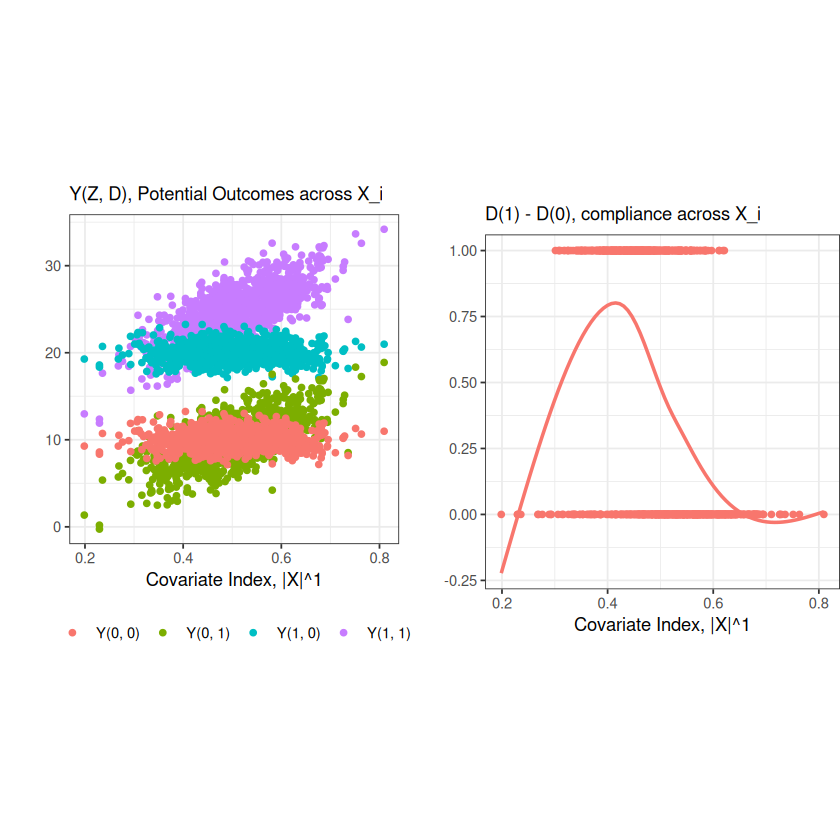

In [8]:
# Simulate covariates with given dimensions.
covariate.dim <- 10
sample.size <- 10^3
# Generate matrix of covariates, along which treatment intensity varies.
min_X <- 0
max_X <- 1 / covariate.dim
X <- runif(sample.size * covariate.dim, min = min_X, max = max_X)
X <- matrix(X, sample.size, covariate.dim)
# Simulate the data, with rho, sigma_0, sigma_1 = 3/4, 1, 2
example.data <- simulate.data(X, 3 / 4, 1, 2)

# Plot the Potential Outcomes
outcomes.plot <- example.data %>%
    ggplot(aes(x = treatment_index_X)) +
    geom_point(aes(y = Y_1_1, colour = "Y(1, 1)")) +
    geom_point(aes(y = Y_1_0, colour = "Y(1, 0)")) +
    geom_point(aes(y = Y_0_1, colour = "Y(0, 1)")) +
    geom_point(aes(y = Y_0_0, colour = "Y(0, 0)")) +
    theme_bw() +
    scale_x_continuous(name = "Covariate Index, |X|^1") +
    scale_y_continuous(name = "") +
    ggtitle("Y(Z, D), Potential Outcomes across X_i") +
    theme(
        plot.title = element_text(size = rel(1)),
        plot.margin = unit(c(0.5, 0, 0, 0), "mm"),
        legend.position = "bottom",
        legend.title = element_blank(),
        aspect.ratio = 1)
# Plot the compliance
compliance.plot <- example.data %>%
    ggplot(aes(x = treatment_index_X)) +
    # geom_point(aes(y = D_1, colour = "D(Z = 1)")) +
    # geom_point(aes(y = D_0, colour = "D(Z = 0)")) +
    geom_point(aes(y = D_1 - D_0, colour = "red")) +
    geom_smooth(aes(y = D_1 - D_0, colour = "red"), se = FALSE) +
    theme_bw() +
    scale_x_continuous(name = "Covariate Index, |X|^1") +
    scale_y_continuous(name = "") +
    ggtitle("D(1) - D(0), compliance across X_i") +
    theme(
        plot.title = element_text(size = rel(1)),
        plot.margin = unit(c(0.5, 0, 0, 0), "mm"),
        legend.position = "none",
        aspect.ratio = 1
    )
# Show the plots.
gridExtra::grid.arrange(outcomes.plot, compliance.plot,
    nrow = 1, heights = unit(10, "cm"))

This system is defined to mimic the assumptions behind causal mediation (Imai, Keele, Yamamoto 2010), but breaking the identifying assumption of mediator $D_i$ randomisation.

$D_i$ is random conditional on $\vec X_i, U_i$, but $U_i$ is unobserved, and so $D_i$ is not random conditional on only $\vec X_i$ if $\rho \neq 0$.

To illustrate this, show the estimates for total effects, indirect effects, and indirect effects compared to known true values (unobserved in real world data) under simulated values $\rho, \sigma_0, \sigma_1 = 3/4, 1, 2$.

In [9]:
# WRITE CODE HERE FOR THE DML EST. and/or linear est, compared to known true values.

# Wrap it in a function that takes simulated.data as input.

Then write about the $R^2_U$ decomposition, and see notes relating them to the Normal distribution.

Then down here loop across pertinent rho, sigma_0, sigma_1 values.